<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
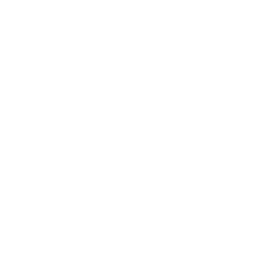
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Αξιοποίηση Πόρων Νοσοκομειακών Τμημάτων — Οριζόντιο Ραβδόγραμμα</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Υγεία / Νοσοκομειακές Λειτουργίες &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Σύνοψη

Αυτό το παράδειγμα χρησιμοποιεί την **PROC GCHART** με οριζόντια ραβδογράμματα (HBAR) για να αποτυπώσει τις ώρες εργασίας του προσωπικού σε έξι κλινικά τμήματα για το 1ο τρίμηνο του 2026. Ένα συνθετικό αρχείο καταγραφής προσωπικού με **90 εγγραφές βαρδιών** (15 ανά τμήμα) τροφοδοτεί τρεις όψεις: ένα ραβδόγραμμα κατάταξης συνολικών ωρών, τη μέση διάρκεια βάρδιας ανά τμήμα, και ομαδοποιημένα HBAR που διαχωρίζουν κάθε τμήμα κατά κατηγορία πόρου και κατά βάρδια. Το `SUMVAR=` αθροίζει τις πραγματικές ώρες εργασίας αντί να μετρά εγγραφές, τα `TYPE=SUM`/`TYPE=MEAN` εναλλάσσουν το στατιστικό απόκρισης, το `DESCENDING` κατατάσσει τα τμήματα, και το `GROUP=` σχεδιάζει παρακείμενες ομαδοποιημένες ράβδους για μια δεύτερη διάσταση.

Η έξοδος υποστηρίζει την τριμηνιαία ανασκόπηση επιχειρησιακής αποδοτικότητας: αναδεικνύει ποια τμήματα καταναλώνουν τις περισσότερες ώρες εργασίας, ποια πραγματοποιούν τις μεγαλύτερες βάρδιες, και πώς διαφέρει το μοτίβο στελέχωσης ημέρας/απογεύματος/νύχτας μεταξύ μονάδων συνεχούς φροντίδας και υπηρεσιών ημερήσιας λειτουργίας.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| WORK.STAFFING_LOG | Ατομικές εγγραφές ωρών εργασίας ανά βάρδια | 90 |
| WORK.DEPT_SUMMARY | Συνολικά στοιχεία και μέση διάρκεια βάρδιας ανά τμήμα | 6 |

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού αρχείου καταγραφής ωρών εργασίας
   νοσοκομειακού προσωπικού. 1ο τρίμηνο 2026: 6 κλινικά
   τμήματα, 4 κατηγορίες πόρων, 3 βάρδιες. Μέγεθος 15
   εγγραφών βάρδιας ανά τμήμα (90 συνολικά) ώστε να
   παραμένει ορατή η πλήρης λίστα τμημάτων.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.staffing_log;
    CALL streaminit(20260601);
    LENGTH department $40 resource_type $40 shift $20;

    /* μείγμα κατηγοριών πόρων (νοσηλευτικά βαρύνουσα στελέχωση) */
    ARRAY resw[4] _temporary_ (0.50 0.20 0.20 0.10);

    /* βασικό μείγμα βαρδιών, με τάση προς τη Νύχτα για μονάδες 24/7 */
    ARRAY shfw[3] _temporary_ (0.45 0.30 0.25);
    ARRAY nightlift[6] _temporary_
        (0.18 0.00 0.22 -0.05 -0.05 0.05);

    ΕΠΑΝΑΛΗΨΗ di = 1 ΕΩΣ 6;
        ΕΑΝ di = 1 ΤΟΤΕ department = 'Επείγοντα';
        ΑΛΛΙΩΣ ΕΑΝ di = 2 ΤΟΤΕ department = 'Χειρουργική';
        ΑΛΛΙΩΣ ΕΑΝ di = 3 ΤΟΤΕ department = 'ΜΕΘ';
        ΑΛΛΙΩΣ ΕΑΝ di = 4 ΤΟΤΕ department = 'Παιδιατρική';
        ΑΛΛΙΩΣ ΕΑΝ di = 5 ΤΟΤΕ department = 'Ογκολογία';
        ΑΛΛΙΩΣ department = 'Μαιευτική';

        ΕΠΑΝΑΛΗΨΗ rec = 1 ΕΩΣ 15;

            /* κατηγορία πόρου μέσω σταθμισμένης επιλογής */
            u = rand('uniform'); cum = 0;
            ΕΠΑΝΑΛΗΨΗ r = 1 ΕΩΣ 4;
                cum + resw[r];
                ΕΑΝ u <= cum ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
                    ΕΑΝ r = 1 ΤΟΤΕ resource_type = 'Νοσηλευτικό';
                    ΑΛΛΙΩΣ ΕΑΝ r = 2 ΤΟΤΕ resource_type = 'Ιατρικό';
                    ΑΛΛΙΩΣ ΕΑΝ r = 3 ΤΟΤΕ resource_type = 'Παραϊατρικό';
                    ΑΛΛΙΩΣ resource_type = 'Υποστήριξη';
                    LEAVE;
                ΤΕΛΟΣ;
            ΤΕΛΟΣ;

            /* βάρδια μέσω τάσης νυχτερινής βάρδιας ανά τμήμα */
            w1 = shfw[1] - nightlift[di] / 2;
            w2 = shfw[2] - nightlift[di] / 2;
            u = rand('uniform');
            ΕΑΝ u <= w1 ΤΟΤΕ shift = 'Ημέρα';
            ΑΛΛΙΩΣ ΕΑΝ u <= w1 + w2 ΤΟΤΕ shift = 'Απόγευμα';
            ΑΛΛΙΩΣ shift = 'Νύχτα';

            /* ώρες: γιατροί και χειρουργική έχουν μεγαλύτερες βάρδιες */
            BASE = 8;
            ΕΑΝ resource_type = 'Ιατρικό' ΤΟΤΕ BASE = BASE + 1.5;
            ΕΑΝ department = 'Χειρουργική'      ΤΟΤΕ BASE = BASE + 1.0;
            hours_worked = round(BASE + rand('normal', 0, 0.8), 0.25);
            ΕΑΝ hours_worked < 4 ΤΟΤΕ hours_worked = 4;

            ΕΞΟΔΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ department resource_type shift hours_worked;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.staffing_log


NOTE: Wrote work.staffing_log (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Συνολικά στοιχεία ανά τμήμα και μέση διάρκεια βάρδιας,
   κατατεταγμένα κατά συνολικές ώρες εργασίας.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SQL;
    CREATE TABLE work.dept_summary AS
    ΕΠΙΛΟΓΗ department,
           sum(hours_worked)  AS total_hours   ΜΟΡΦΗ=8.2,
           count(*)           AS shift_count,
           mean(hours_worked) AS avg_shift_hrs  ΜΟΡΦΗ=6.2
    FROM work.staffing_log
    GROUP ΚΑΤΑ department
    ORDER ΚΑΤΑ total_hours DESC;
QUIT;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=work.dept_summary noobs ΕΤΙΚΕΤΑ;
    ΕΤΙΚΕΤΑ department    = 'Τμήμα'
          total_hours   = 'Σύνολο Ωρών'
          shift_count   = 'Αριθμός Βαρδιών'
          avg_shift_hrs = 'Μέση Βάρδια (ώρες)';
    TITLE 'Σύνοψη Εργατοωρών ανά Τμήμα - 1ο Τρίμηνο 2026';
ΕΚΤΕΛΕΣΗ;
TITLE;

                                     Σύνοψη Εργατοωρών ανά Τμήμα - 1ο Τρίμηνο 2026                                      

                 Τμήμα            Σύνολο Ωρών                Αριθμός Βαρδιών                Μέση Βάρδια (ώρες)
Χειρουργική                            136.25                             15                              9.08
ΜΕΘ                                    128.50                             15                              8.57
Μαιευτική                              127.75                             15                              8.52
Παιδιατρική                            124.75                             15                              8.32
Ογκολογία                              123.75                             15                              8.25
Επείγοντα                              119.25                             15                              7.95




NOTE: PROC SQL 

NOTE: Table work.dept_summary created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.dept_summary

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


---

                                                Ώρες Εργασίας ανά Τμήμα                                                 

                                                  The MEANS Procedure

                               Analysis Variable : hours_worked Ώρες Εργασίας

        Τμήμα                             Sum           Mean          N Obs
        -------------------------------------------------------------------
        Επείγοντα                      119.25           7.95             15
        ΜΕΘ                            128.50           8.57             15
        Μαιευτική                      127.75           8.52             15
        Ογκολογία                      123.75           8.25             15
        Παιδιατρική                    124.75           8.32             15
        Χειρουργική                    136.25           9.08             15
        -------------------------------------------------------------------

                                           


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_shift.spec.json
NOTE: PROC FREQ statement used.


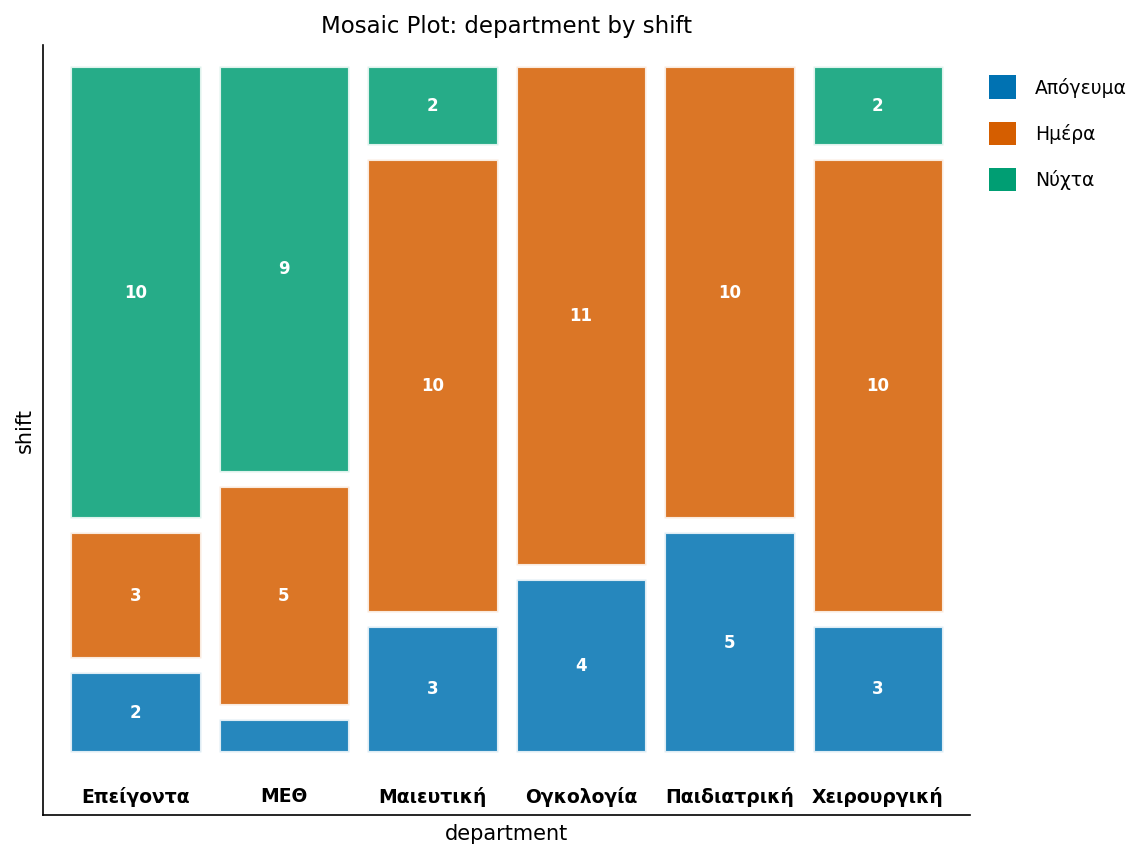

In [3]:
/* --------------------------------------------------------
   Βασικοί πίνακες: ώρες εργασίας ανά τμήμα, και κατανομή
   βαρδιών ημέρας / απογεύματος / νύχτας ανά τμήμα.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.staffing_log sum mean n maxdec=2;
    ΚΛΑΣΗ department;
    ΜΕΤΑΒΛΗΤΗ hours_worked;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' hours_worked = 'Ώρες Εργασίας';
    TITLE 'Ώρες Εργασίας ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.staffing_log;
    TABLES department * shift / norow nocol nopercent;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' shift = 'Βάρδια';
    TITLE 'Κατανομή Βαρδιών ανά Τμήμα';
ΕΚΤΕΛΕΣΗ;
TITLE;

---


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


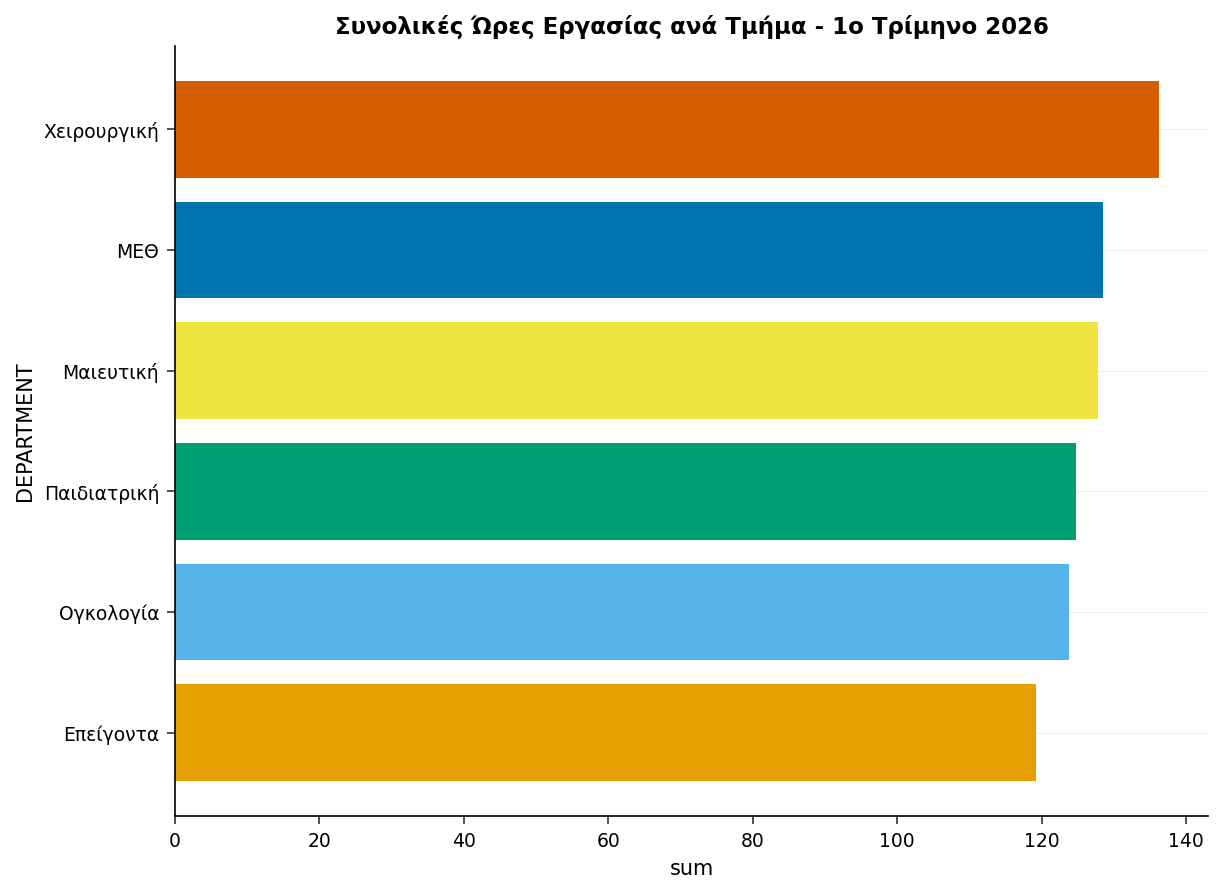

In [4]:
/* --------------------------------------------------------
   Συνολικό HBAR: συνολικές ώρες εργασίας ανά τμήμα.
   Το SUMVAR= αθροίζει ώρες- το DESCENDING κατατάσσει τις ράβδους.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ GCHART ΔΕΔΟΜΕΝΑ=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=sum
                      DESCENDING;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' hours_worked = 'Ώρες Εργασίας';
    TITLE 'Συνολικές Ώρες Εργασίας ανά Τμήμα - 1ο Τρίμηνο 2026';
ΕΚΤΕΛΕΣΗ;
QUIT;
TITLE;

### Κατανομή κάθε τμήματος κατά κατηγορία πόρου

Το `GROUP=` σχεδιάζει μια δέσμη παρακείμενων οριζόντιων ράβδων για κάθε τμήμα, μία ράβδο ανά κατηγορία πόρου. Επειδή ισχύει το `SUMVAR=hours_worked`, κάθε ράβδος μετρά τις συσσωρευμένες ώρες εργασίας αντί για αριθμό εγγραφών, οπότε το γράφημα δείχνει πώς συγκρίνονται οι ώρες νοσηλευτικού, ιατρικού, παραϊατρικού και υποστηρικτικού προσωπικού *εντός* κάθε τμήματος.

In [5]:
/* --------------------------------------------------------
   Δηλώσεις PATTERN: συντονισμένη παλέτα 4 χρωμάτων,
   ένα pattern ανά υποομάδα κατηγορίας πόρου
   -------------------------------------------------------- */
pattern1 VALUE=solid color=cx2C5F8A;   /* Νοσηλευτικό — βαθύ μπλε */
pattern2 VALUE=solid color=cx28A745;   /* Ιατρικό — πράσινο */
pattern3 VALUE=solid color=cxE8650A;   /* Παραϊατρικό — πορτοκαλί */
pattern4 VALUE=solid color=cx6C757D;   /* Υποστήριξη — γκρι */

                                      Ώρες Εργασίας ανά Τμήμα και Κατηγορία Πόρου                                       


Πηγή: Σύστημα Διαχείρισης Ανθρώπινου Δυναμικού | Περίοδος αναφοράς: Ιαν-Μαρ 2026



NOTE: Option TITLE changed to Ώρες Εργασίας ανά Τμήμα και Κατηγορία Πόρου.
NOTE: Option FOOTNOTE changed to Πηγή: Σύστημα Διαχείρισης Ανθρώπινου Δυναμικού | Περίοδος αναφοράς: Ιαν-Μαρ 2026.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


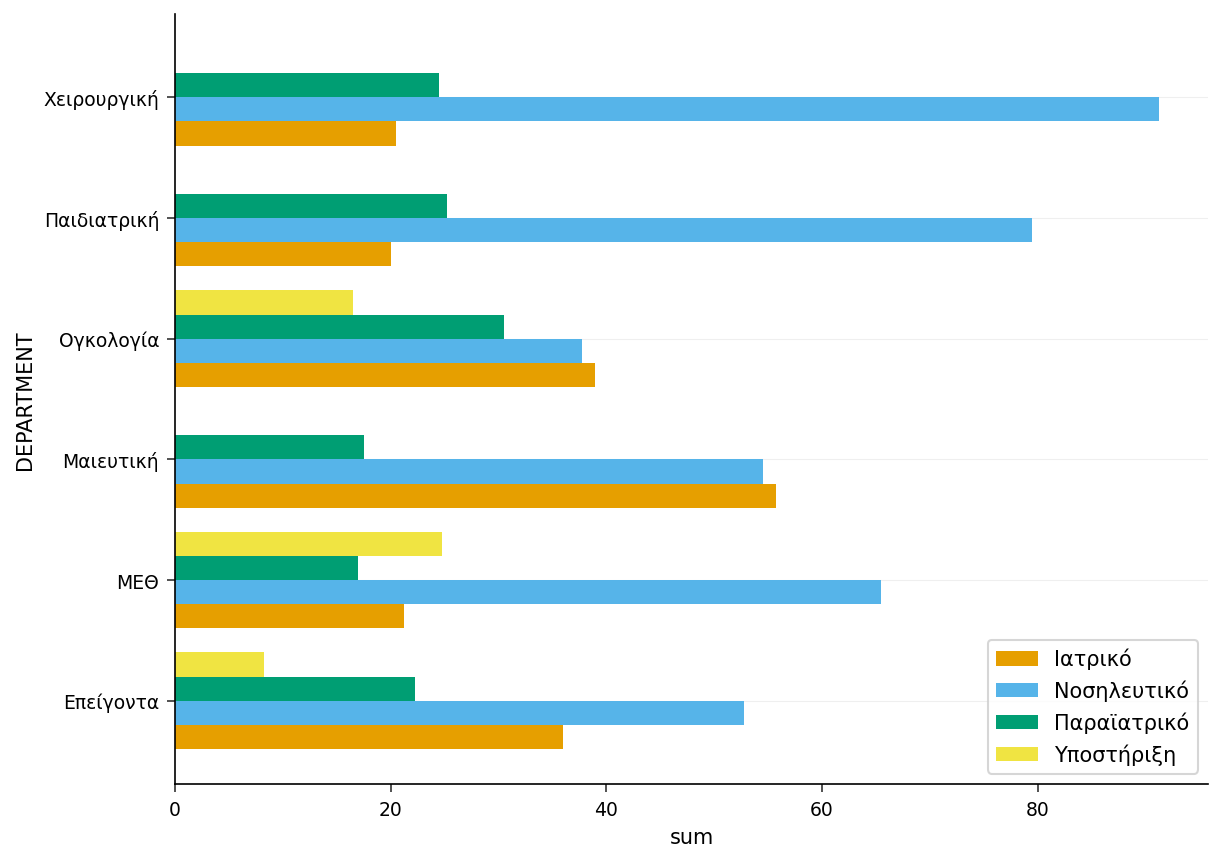

In [6]:
/* --------------------------------------------------------
   HBAR ομαδοποιημένο κατά κατηγορία πόρου (GROUP=).
   Κάθε τμήμα γίνεται μια δέσμη ράβδων -- μία ανά
   κατηγορία πόρου -- μετρημένη σε συσσωρευμένες ώρες εργασίας.
   -------------------------------------------------------- */
TITLE 'Ώρες Εργασίας ανά Τμήμα και Κατηγορία Πόρου';
footnote JUSTIFY=LEFT
    'Πηγή: Σύστημα Διαχείρισης Ανθρώπινου Δυναμικού | Περίοδος αναφοράς: Ιαν-Μαρ 2026';

ΔΙΑΔΙΚΑΣΙΑ GCHART ΔΕΔΟΜΕΝΑ=work.staffing_log;
    HBAR department / GROUP=resource_type
                      SUMVAR=hours_worked
                      type=sum;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' resource_type = 'Κατηγορία Πόρου' hours_worked = 'Ώρες Εργασίας';
ΕΚΤΕΛΕΣΗ;
QUIT;

TITLE; footnote;

                                           Ώρες Εργασίας ανά Τμήμα και Βάρδια                                           


Οι ομαδοποιημένες ράβδοι διαχωρίζουν τη συμβολή Ημέρα / Απόγευμα / Νύχτα ανά τμήμα



NOTE: Option TITLE changed to Ώρες Εργασίας ανά Τμήμα και Βάρδια.
NOTE: Option FOOTNOTE changed to Οι ομαδοποιημένες ράβδοι διαχωρίζουν τη συμβολή Ημέρα / Απόγευμα / Νύχτα ανά τμήμα.
NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


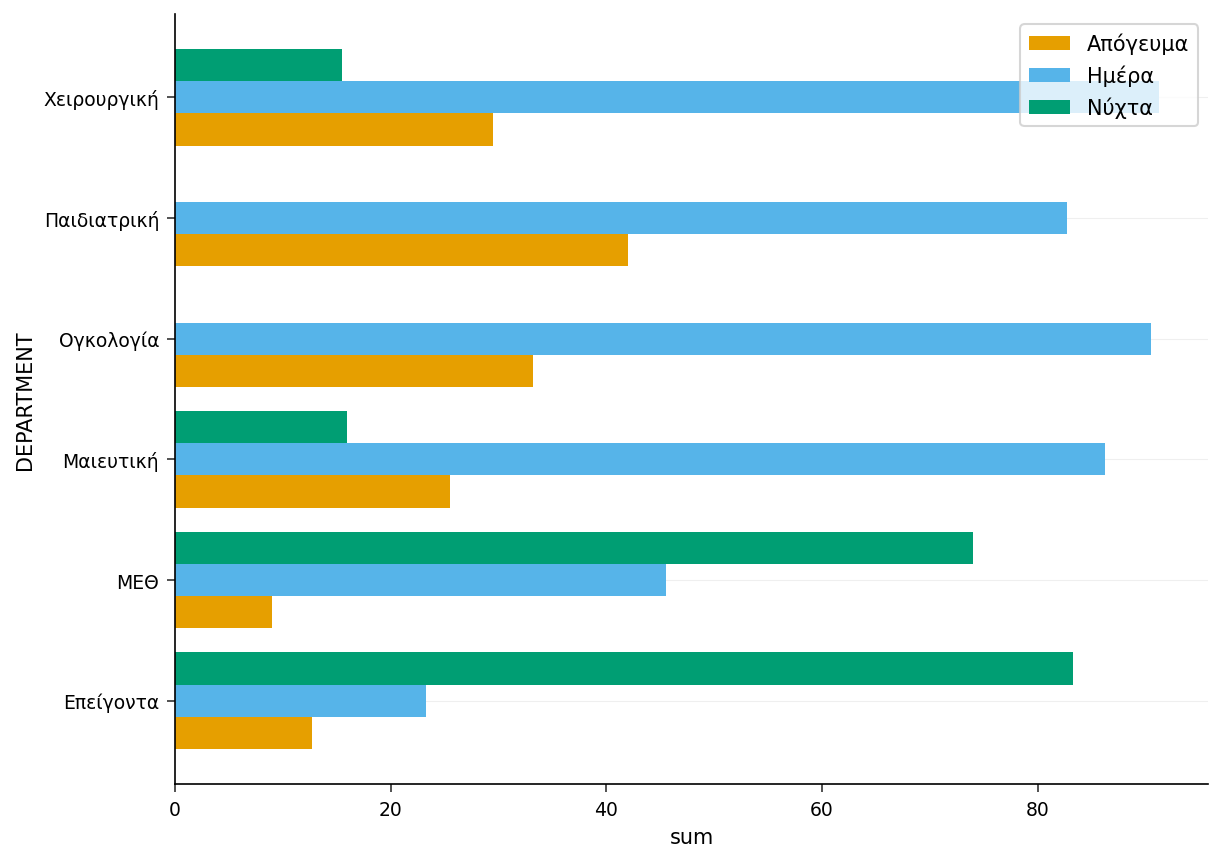

In [7]:
/* --------------------------------------------------------
   HBAR ομαδοποιημένο κατά βάρδια (GROUP=).
   Διαχωρίζει τις ώρες εργασίας Ημέρας / Απογεύματος / Νύχτας
   εντός κάθε τμήματος -- αναδεικνύοντας τις μονάδες 24/7.
   -------------------------------------------------------- */
TITLE 'Ώρες Εργασίας ανά Τμήμα και Βάρδια';
footnote JUSTIFY=LEFT
    'Οι ομαδοποιημένες ράβδοι διαχωρίζουν τη συμβολή Ημέρα / Απόγευμα / Νύχτα ανά τμήμα';

ΔΙΑΔΙΚΑΣΙΑ GCHART ΔΕΔΟΜΕΝΑ=work.staffing_log;
    HBAR department / GROUP=shift
                      SUMVAR=hours_worked
                      type=sum;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' shift = 'Βάρδια' hours_worked = 'Ώρες Εργασίας';
ΕΚΤΕΛΕΣΗ;
QUIT;

TITLE; footnote;


NOTE: PROC GCHART data=work.staffing_log

NOTE: ODS plot written: gchart_hbar.spec.json


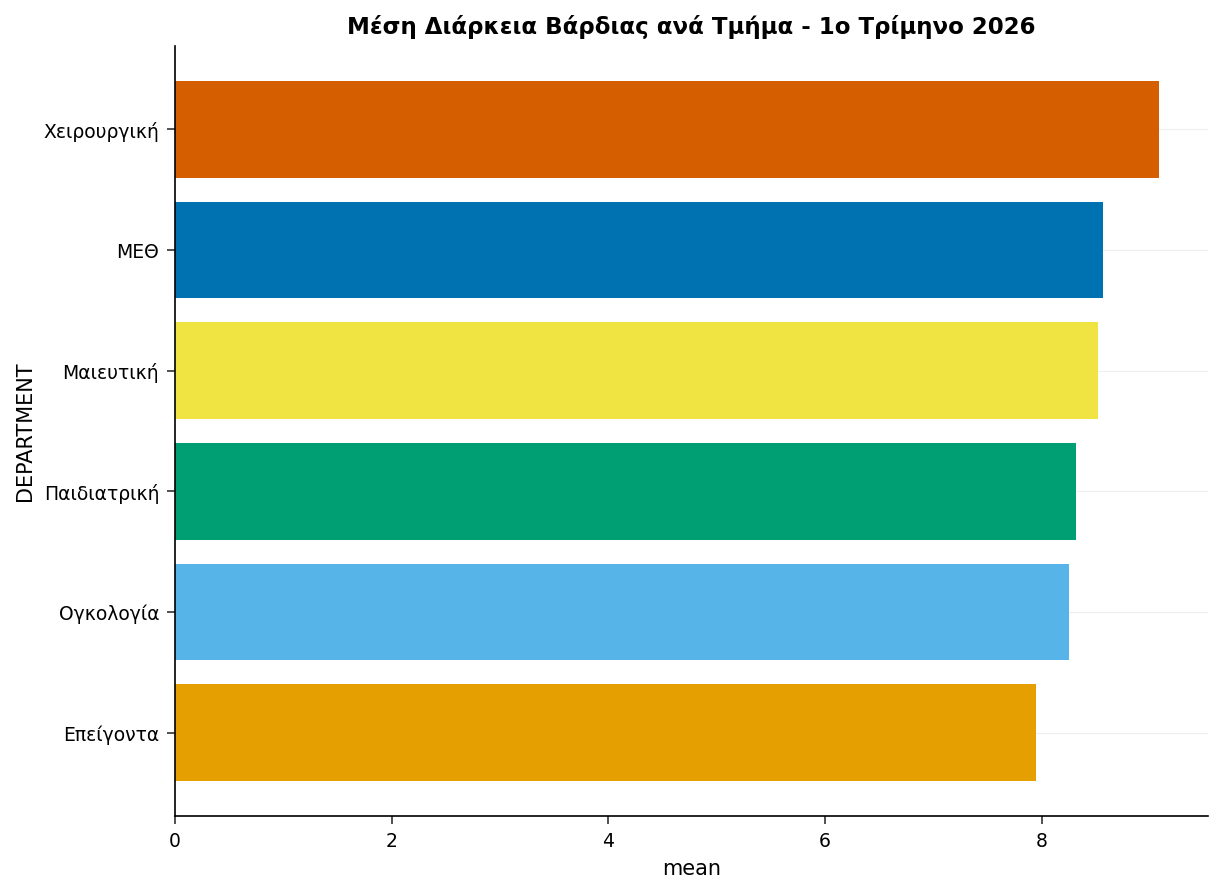

In [8]:
/* --------------------------------------------------------
   Μέση διάρκεια βάρδιας ανά τμήμα (TYPE=MEAN).
   Αποκαλύπτει αν ένα τμήμα έχει μεγάλες βάρδιες ή πολλές
   μικρότερες, ανεξάρτητα από τον συνολικό όγκο.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ GCHART ΔΕΔΟΜΕΝΑ=work.staffing_log;
    HBAR department / SUMVAR=hours_worked
                      type=mean
                      DESCENDING;
    ΕΤΙΚΕΤΑ department = 'Τμήμα' hours_worked = 'Ώρες Εργασίας';
    TITLE 'Μέση Διάρκεια Βάρδιας ανά Τμήμα - 1ο Τρίμηνο 2026';
ΕΚΤΕΛΕΣΗ;
QUIT;
TITLE;

---

### Ερμηνεία

Στις 90 εγγραφές βαρδιών, οι συνολικές ώρες εργασίας κυμαίνονται σε ένα στενό εύρος από **119.25** (Επείγοντα) έως **136.25** (Χειρουργική), επειδή κάθε τμήμα περιλαμβάνει τις ίδιες 15 βάρδιες σε αυτή την περίοδο — οπότε η κατάταξη αντανακλά τη **διάρκεια βάρδιας**, όχι τον αριθμό βαρδιών. Η Χειρουργική βρίσκεται στην κορυφή τόσο στο γράφημα συνολικών ωρών όσο και στο γράφημα μέσης βάρδιας με **9.08 ώρες** ανά βάρδια, συνεπές με τις μεγαλύτερες χειρουργικές επεμβάσεις και την ιατρική στελέχωση που απαιτούν. Τα Επείγοντα βρίσκονται στο κάτω μέρος σε ώρες (μέσος όρος **7.95**) παρότι είναι μία από τις πιο πολυάσχολες μονάδες, επειδή η εργασία τους πραγματοποιείται σε συντομότερες βάρδιες με μεγαλύτερη εναλλαγή προσωπικού.

Το HBAR ομαδοποιημένο κατά βάρδια και ο πίνακας μωσαϊκού αποκαλύπτουν την επιχειρησιακά σημαντική εικόνα. **Τα Επείγοντα και η ΜΕΘ κυριαρχούνται από νυχτερινές βάρδιες** — 10 στις 15 και 9 στις 15 βάρδιες αντίστοιχα πέφτουν στη Νύχτα — ενώ **η Ογκολογία και η Παιδιατρική δεν καταγράφουν καμία νυχτερινή βάρδια** και συγκεντρώνονται στην κάλυψη Ημέρας (11 και 10 βάρδιες Ημέρας). Αυτός ο διαχωρισμός αντικατοπτρίζει την πραγματική νοσοκομειακή στελέχωση: οι μονάδες συνεχούς φροντίδας λειτουργούν όλο το 24ωρο, ενώ η ογκολογική έγχυση και η γενική παιδιατρική είναι ημερήσιες υπηρεσίες. Το πάνελ κατηγορίας πόρου επιβεβαιώνει ένα **μείγμα με πρωταγωνιστικό ρόλο του νοσηλευτικού προσωπικού** σε κάθε τμήμα, με τις ώρες ιατρικού και παραϊατρικού προσωπικού να αποτελούν τα δευτερεύοντα επίπεδα.

Για την ανασκόπηση στελέχωσης του 2ου τριμήνου, η συγκέντρωση νυχτερινών βαρδιών στα Επείγοντα και τη ΜΕΘ είναι το σημείο προσοχής: εκεί συσσωρεύεται το κόστος υπερωριακής αμοιβής και διαχείρισης κόπωσης, και εκεί οποιαδήποτε αλλαγή στο πρόγραμμα βαρδιών έχει τη μεγαλύτερη επίπτωση στον προϋπολογισμό.

---

In [9]:
/* --------------------------------------------------------
   Εξαγωγή της σύνοψης τμημάτων για το σύστημα
   προγραμματισμού εργατικού δυναμικού.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.dept_summary
    OUTFILE='q1_dept_labor_summary.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.dept_summary outfile=q1_dept_labor_summary.csv

NOTE: Exported 6 rows to q1_dept_labor_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>